In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data

In [2]:
df = pd.read_csv('../data/subset_data_pre_thru_week3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

In [4]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


Distribution of final_result:

Absolute counts:
final_result
Pass           6242
Fail           3020
Withdrawn      2677
Distinction    1537
Name: count, dtype: int64

Percentage distribution:
final_result
Pass           46.319383
Fail           22.410211
Withdrawn      19.864945
Distinction    11.405462
Name: proportion, dtype: float64


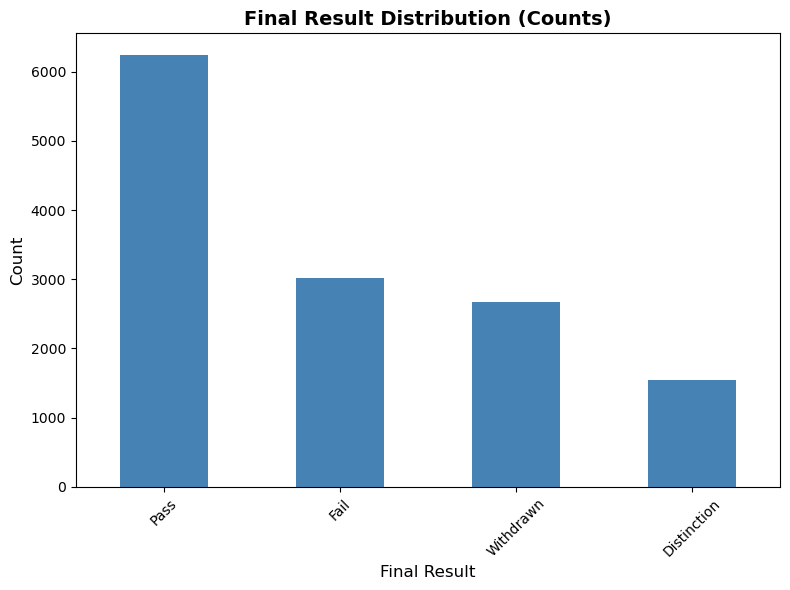


Total students: 13476
Unique categories: 4


In [5]:
# Examine the distribution of final_result

print("Distribution of final_result:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['final_result'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['final_result'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Final Result Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique categories: {df['final_result'].nunique()}")

## Data preprocessing

In [6]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
# Not included: demographic features + relative_submission_date (because it would cause student who never submitted to get dropped)
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'std_weekly_consistency_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    'submission_type',
    'total_vle_pre_w3',
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type
columns_to_fill_zeros = [
    'std_weekly_consistency_pre_w3',
    'std_regularity_pre_w3',
]
df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
df_model_clean = df_model.dropna() 


## Initial train-test split

In [7]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']


# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

In [8]:
# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {X["code_module"].value_counts(normalize = True).sort_index().values}")
print(f"Train:      {X["code_module"].loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {X["code_module"].loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57724844 0.42275156]
Train (1 = At-Risk):    [0.57717996 0.42282004]
Test (1 = At-Risk):     [0.57752226 0.42247774]

Module distribution:
------------------------------------------------------------
Original:   [0.05060849 0.39611161 0.24918373 0.08860196 0.21549421]
Train:      [0.05055659 0.3961039  0.24925788 0.08858998 0.21549165]
Test:       [0.05081602 0.39614243 0.24888724 0.08864985 0.21550445]


## Define models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost.sklearn import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'std_weekly_consistency_pre_w3',
              'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
              'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

In [11]:
# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                     ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                     penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                     class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                               ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                   min_samples_split=50, min_samples_leaf=25,
                                                                   max_features='sqrt', max_samples=0.7,
                                                                   class_weight='balanced'))]),
    'Gradient Boosting': Pipeline([('preprocess', cat_processor),
                                   ('classify', GradientBoostingClassifier(random_state=SEED, n_estimators=100, 
                                                                          max_depth=3, learning_rate=0.1))]),
    'Extra Trees': Pipeline([('preprocess', cat_processor),
                            ('classify', ExtraTreesClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                             min_samples_split=50, min_samples_leaf=25,
                                                             max_features='sqrt', class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                         ('classify', XGBClassifier(random_state=SEED))])
}

## Train and compare models

In [12]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate

Note we have marked "Pass / Distinction" as 0 and "Fail / Withdrawn [after week 4]" as 1. With this encoding, "positive" classifications are "Fail / Withdrawn", and "negative" classifications are "Pass / Distinction" (in short: we are classifying whether a student is "at risk" or not.) Hence:
- the recall (also known as sensitivity) gives the proportion of at-risk students that the model correctly identifies;
- the specificty gives the proportion of not-at-risk students that the model correctly identifies;
- the precision gives the proportion of students flagged as at-risk by the model that actually fail / withdraw.
Maximizing recall corresponds to identifying as many at-risk students as possible; increasing precision corresponds to reducing the number of false positives. 

### Cross-validation using `StratifiedKFold`

In [13]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']

## Keep extra copy of column in X_train for further use in cross-validation splits
X["stratify"] = stratify_column

# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Set X_train, y_train up for stratified splits during cross-validation
y_train = X_train["stratify"]
X_train.drop(["stratify"], axis=1, inplace=True)

In [14]:
from sklearn.model_selection import StratifiedKFold

# Train and evaluate with cross-validation
results = []
skf = StratifiedKFold(n_splits=5)

for model in models:
    auc, recall, precision, f1, overfit_gap = [], [], [], [], []
    for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_index]
        y_tt = y_train.iloc[train_index].apply(lambda x: int(x[0]))

        X_ho = X_train.iloc[test_index]
        y_ho = y_train.iloc[test_index].apply(lambda x: int(x[0]))   
        
        this_model = clone(models[model])
        this_model.fit(X_tt, y_tt)
    
        y_test_pred = this_model.predict(X_ho)
        y_train_pred = this_model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = this_model.predict_proba(X_ho)[:, 1]
            y_train_proba = this_model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        precision += [precision_score(y_ho, y_test_pred)]
        f1 += [f1_score(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]
 
    # Metrics averaged across all folds
    results.append({
        'Model': model,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Precision': np.mean(precision),
        'Test F1': np.mean(f1),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

In [15]:
results_df

,Model,Test ROC-AUC,Test Recall,Test Precision,Test F1,Overfitting Gap
1,Logistic Regression,0.708126,0.614956,0.589177,0.601748,0.000649
4,Extra Trees,0.698059,0.627685,0.561549,0.592684,0.004082
2,Random Forest,0.708082,0.580945,0.603463,0.591851,0.016002
3,Gradient Boosting,0.706104,0.453261,0.656252,0.535893,0.027876
5,XGBoost,0.667240,0.470376,0.588424,0.522668,0.257607
0,Baseline (Stratified),0.498289,0.428914,0.420883,0.424860,0.009485


In [16]:
# Display results
print("\nMODEL PERFORMANCE (Cross-Validation)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ BEST ROC-AUC: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%}")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP ROC-AUC: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Recall: {runner_up['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {runner_up['Test Precision']:.1%}")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Cross-Validation)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7081       0.6150          0.5892   0.6017           0.0006
          Extra Trees        0.6981       0.6277          0.5615   0.5927           0.0041
        Random Forest        0.7081       0.5809          0.6035   0.5919           0.0160
    Gradient Boosting        0.7061       0.4533          0.6563   0.5359           0.0279
              XGBoost        0.6672       0.4704          0.5884   0.5227           0.2576
Baseline (Stratified)        0.4983       0.4289          0.4209   0.4249           0.0095

KEY INSIGHTS

✓ BEST ROC-AUC: Logistic Regression
  • ROC-AUC: 0.708 (+0.210 vs baseline)
  • Recall: 61.5% of at-risk students identified
  • Precision: 58.9%
  • Overfitting: 0.001 ✓ Well-controlled

✓ RUNNER-UP ROC-AUC: Extra Trees
  • ROC-

In [17]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'Extra Trees': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    }
}

models_to_tune = ['Logistic Regression', 'Random Forest', 'Extra Trees']
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(clone(models[model_name]), param_grids[model_name], 
                        cv=5, scoring='recall', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train_numeric)
    print(f"Best params: {grid.best_params_}")
    print(f"Best recall: {grid.best_score_:.4f}")
    final_models[model_name] = grid.best_estimator_

tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']
tuned_et_model = final_models['Extra Trees']


Tuning Logistic Regression...
Fitting 5 folds for each of 99 candidates, totalling 495 fits
Best params: {'classify__C': 0.01, 'classify__l1_ratio': 0.0}
Best recall: 0.6286

Tuning Random Forest...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 10, 'classify__min_samples_leaf': 50, 'classify__min_samples_split': 25, 'classify__n_estimators': 100}
Best recall: 0.6014

Tuning Extra Trees...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 4, 'classify__min_samples_leaf': 10, 'classify__min_samples_split': 100, 'classify__n_estimators': 200}
Best recall: 0.6365


## Analysis of false positives

In [18]:
# Get false positives from Logistic Regression & Random Forest (tuned models)
y_train_numeric = y_train.apply(lambda x: int(x[0]))

# Analyze both models
for model_name, model in [('Logistic Regression', tuned_lr_model), ('Random Forest', tuned_rf_model)]:
    print(f"\n{'='*60}\n{model_name.upper()} - FALSE POSITIVES\n{'='*60}")
    
    y_pred = model.predict(X_train)
    false_positive_mask = (y_pred == 1) & (y_train_numeric == 0)
    
    false_positives = X_train[false_positive_mask].copy()
    false_positives['actual_outcome'] = 'Pass/Distinction'
    false_positives['predicted_outcome'] = 'At-Risk'
    false_positives['predicted_probability'] = model.predict_proba(X_train)[:, 1][false_positive_mask]
    
    print(f"False Positives: {len(false_positives)} ({len(false_positives)/len(X_train)*100:.1f}%)")


LOGISTIC REGRESSION - FALSE POSITIVES
False Positives: 2045 (19.0%)

RANDOM FOREST - FALSE POSITIVES
False Positives: 1736 (16.1%)


In [19]:
# Compare false vs true positives for both models
y_train_numeric = y_train.apply(lambda x: int(x[0]))
feature_cols = ['total_vle_pre_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
                'std_weekly_consistency_pre_w3', 'std_regularity_pre_w3', 
                'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'score']

for model_name, model in [('Logistic Regression', tuned_lr_model), ('Random Forest', tuned_rf_model)]:
    print(f"\n{'='*80}\n{model_name.upper()} - FALSE vs TRUE POSITIVES\n{'='*80}")
    
    y_pred = model.predict(X_train)
    
    # Get false and true positives
    fp_mask = (y_pred == 1) & (y_train_numeric == 0)
    tp_mask = (y_pred == 1) & (y_train_numeric == 1)
    
    false_positives = X_train[fp_mask].copy()
    true_positives = X_train[tp_mask].copy()
    
    # Merge score back from original df
    false_positives['score'] = df.loc[false_positives.index, 'score'].values
    true_positives['score'] = df.loc[true_positives.index, 'score'].values
    
    print(f"False Positives: {len(false_positives)} ({len(false_positives)/len(X_train)*100:.1f}%)")
    print(f"True Positives:  {len(true_positives)} ({len(true_positives)/len(X_train)*100:.1f}%)")
    
    # Feature comparison
    comparison = pd.DataFrame({
        'FP Mean': false_positives[feature_cols].mean(),
        'TP Mean': true_positives[feature_cols].mean()
    })
    comparison['Difference'] = comparison['FP Mean'] - comparison['TP Mean']
    
    print("\nFeature Comparison:")
    print(comparison.round(3).to_string())
    
    # Submission type comparison
    print("\nSubmission Type Distribution:")
    fp_submission = false_positives['submission_type'].value_counts(normalize=True) * 100
    tp_submission = true_positives['submission_type'].value_counts(normalize=True) * 100
    submission_comparison = pd.DataFrame({
        'FP %': fp_submission,
        'TP %': tp_submission
    }).fillna(0)
    print(submission_comparison.round(1).to_string())
    
    # Top differences
    print("\nTop 3 Most Different Features:")
    top_diffs = comparison['Difference'].abs().nlargest(3)
    for feat in top_diffs.index:
        diff = comparison.loc[feat, 'Difference']
        direction = "higher" if diff > 0 else "lower"
        print(f"  {feat}: FP are {abs(diff):.2f} {direction} than TP")


LOGISTIC REGRESSION - FALSE vs TRUE POSITIVES
False Positives: 2045 (19.0%)
True Positives:  2846 (26.4%)

Feature Comparison:
                               FP Mean  TP Mean  Difference
total_vle_pre_w3               196.177  145.309      50.867
content_focus_pre_w3             0.572    0.598      -0.026
collaborative_focus_pre_w3       0.147    0.136       0.011
std_weekly_consistency_pre_w3    1.105    0.939       0.166
std_regularity_pre_w3            2.877    2.864       0.013
vle_richness_pre_w3              6.271    5.770       0.501
diversity_shannon_pre_w3         1.841    1.752       0.089
score                           75.839   61.240      14.598

Submission Type Distribution:
                 FP %  TP %
submission_type            
Early            87.7  69.1
Late             10.0   7.1
Never             2.3  23.8

Top 3 Most Different Features:
  total_vle_pre_w3: FP are 50.87 higher than TP
  score: FP are 14.60 higher than TP
  vle_richness_pre_w3: FP are 0.50 higher th

In [20]:
# Statistical analysis: FP vs TP
from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL COMPARISON: False Positives vs True Positives")
print("=" * 80)

# Numerical features (score already added in previous cell)
numerical_cols = ['total_vle_pre_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
                  'std_weekly_consistency_pre_w3', 'std_regularity_pre_w3', 
                  'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'score']

stats_results = []

for feature in numerical_cols:
    fp_vals = false_positives[feature].dropna()
    tp_vals = true_positives[feature].dropna()
    
    t_stat, p_val = stats.ttest_ind(fp_vals, tp_vals)
    
    stats_results.append({
        'Feature': feature,
        'FP Mean': fp_vals.mean(),
        'TP Mean': tp_vals.mean(),
        'Diff': fp_vals.mean() - tp_vals.mean(),
        'p-value': p_val,
        'Sig': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    })

# Display results
stats_df = pd.DataFrame(stats_results).sort_values('p-value')
print("\n" + stats_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Key findings
print("\n" + "=" * 80)
sig = stats_df[stats_df['p-value'] < 0.05]
print(f"Significant differences ({len(sig)}/{len(stats_df)} features):")
for _, row in sig.iterrows():
    direction = "higher" if row['Diff'] > 0 else "lower"
    print(f"  {row['Feature']}: FP {abs(row['Diff']):.2f} {direction} (p={row['p-value']:.4f})")


STATISTICAL COMPARISON: False Positives vs True Positives

                      Feature  FP Mean  TP Mean   Diff  p-value Sig
                        score   74.969   61.401 13.568    0.000 ***
          vle_richness_pre_w3    6.105    5.752  0.353    0.000 ***
             total_vle_pre_w3  154.900  136.881 18.019    0.000 ***
std_weekly_consistency_pre_w3    1.011    0.926  0.086    0.000 ***
     diversity_shannon_pre_w3    1.827    1.761  0.066    0.001 ***
        std_regularity_pre_w3    3.029    2.869  0.160    0.050   *
         content_focus_pre_w3    0.605    0.618 -0.013    0.142    
   collaborative_focus_pre_w3    0.135    0.132  0.004    0.474    

Significant differences (6/8 features):
  score: FP 13.57 higher (p=0.0000)
  vle_richness_pre_w3: FP 0.35 higher (p=0.0000)
  total_vle_pre_w3: FP 18.02 higher (p=0.0000)
  std_weekly_consistency_pre_w3: FP 0.09 higher (p=0.0000)
  diversity_shannon_pre_w3: FP 0.07 higher (p=0.0007)
  std_regularity_pre_w3: FP 0.16 higher (p


LOGISTIC REGRESSION - THRESHOLD ANALYSIS


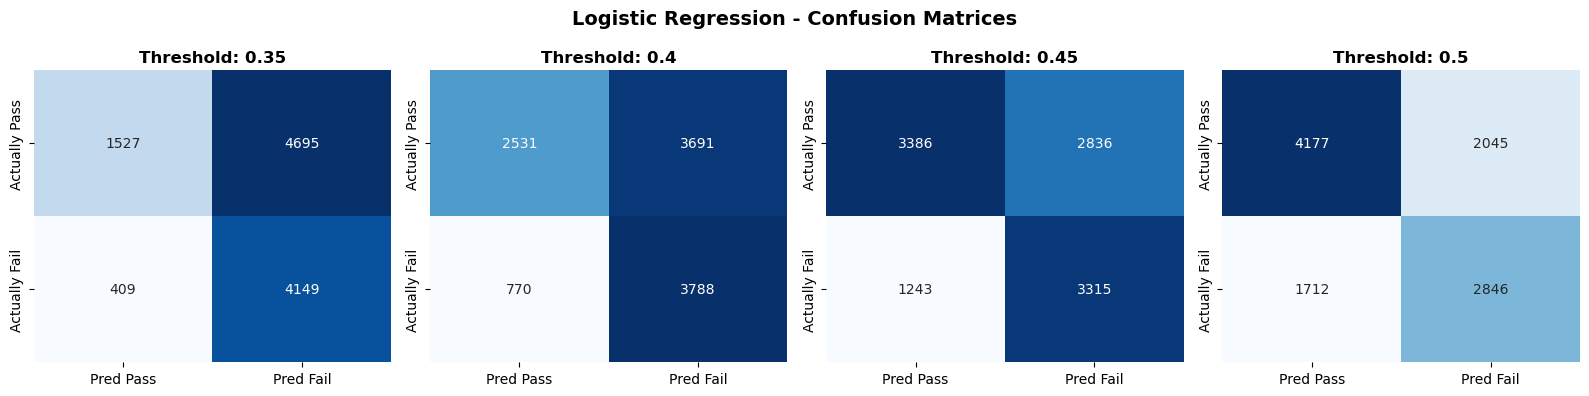


 Threshold  True Positive  False Positive  Flagged (#) Flagged (%) Actual Fail (%) Recall TP/FP Ratio
0.35       4149           4695            8844         82.0%       42.3%           91.0%  0.88       
0.40       3788           3691            7479         69.4%       42.3%           83.1%  1.03       
0.45       3315           2836            6151         57.1%       42.3%           72.7%  1.17       
0.50       2846           2045            4891         45.4%       42.3%           62.4%  1.39       

Total students in training set: 10780

RANDOM FOREST - THRESHOLD ANALYSIS


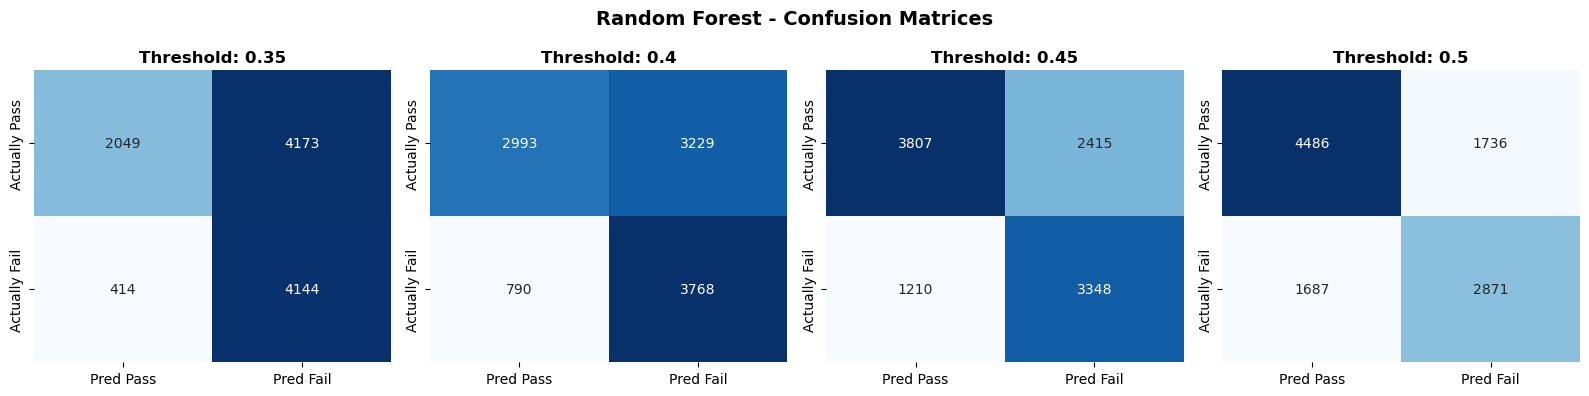


 Threshold  True Positive  False Positive  Flagged (#) Flagged (%) Actual Fail (%) Recall TP/FP Ratio
0.35       4144           4173            8317         77.2%       42.3%           90.9%  0.99       
0.40       3768           3229            6997         64.9%       42.3%           82.7%  1.17       
0.45       3348           2415            5763         53.5%       42.3%           73.5%  1.39       
0.50       2871           1736            4607         42.7%       42.3%           63.0%  1.65       

Total students in training set: 10780


In [21]:
# Analyze FP vs TP at specific thresholds with confusion matrices
from sklearn.metrics import confusion_matrix, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.35, 0.4, 0.45, 0.5]

for model_name, model in [('Logistic Regression', tuned_lr_model), ('Random Forest', tuned_rf_model)]:
    print(f"\n{'='*80}\n{model_name.upper()} - THRESHOLD ANALYSIS\n{'='*80}")
    
    y_proba = model.predict_proba(X_train)[:, 1]
    
    # Calculate actual failing ratio (same for all thresholds)
    actual_fail_count = y_train_numeric.sum()
    actual_fail_ratio = actual_fail_count / len(X_train)
    
    # Create confusion matrix visualizations
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    results = []
    for idx, threshold in enumerate(thresholds):
        y_pred = (y_proba >= threshold).astype(int)
        
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)  # Predicted at-risk, actually passed
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)  # Predicted at-risk, actually at-risk
        
        fp_count = fp_mask.sum()
        tp_count = tp_mask.sum()
        total_predicted = fp_count + tp_count
        flagged_pct = total_predicted / len(X_train)
        
        # Calculate recall
        recall = recall_score(y_train_numeric, y_pred)
        
        results.append({
            'Threshold': threshold,
            'True Positive': tp_count,
            'False Positive': fp_count,
            'Flagged (#)': total_predicted,
            'Flagged (%)': f"{flagged_pct*100:.1f}%",
            'Actual Fail (%)': f"{actual_fail_ratio*100:.1f}%",
            'Recall': f"{recall*100:.1f}%",
            'TP/FP Ratio': f"{tp_count/fp_count:.2f}" if fp_count > 0 else "inf"
        })
        
        # Plot confusion matrix
        cm = confusion_matrix(y_train_numeric, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                    xticklabels=['Pred Pass', 'Pred Fail'],
                    yticklabels=['Actually Pass', 'Actually Fail'],
                    cbar=False)
        axes[idx].set_title(f'Threshold: {threshold}', fontweight='bold')
    
    plt.suptitle(f'{model_name} - Confusion Matrices', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print table
    results_df = pd.DataFrame(results)
    print("\n" + results_df.to_string(index=False, justify='left'))
    print(f"\nTotal students in training set: {len(X_train)}")

In [22]:
# Compare false positive profiles across different "at-risk" definitions
# Central question: how many of the false positives (i.e. students incorrectly flagged as failing) were actually at-risk by week 3?
# All "at-risk" definitions included students who: 
# (a) never submitted their first assignment,
# (b) got a score of less than 70 on their first assignment, and/or
# (c) logged fewer than 112.5 VLE interactions (the median of failing students) through the end of week 3
# The fourth condition varied depending on how we defined an "at-risk" late submission: all late submissions, or only those submitted after 3 and 7 days late?

y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.35, 0.4, 0.45, 0.5]

# Define 3 scenarios for the submission timing risk factor
scenarios = {
    'A: Late submission': lambda fp: fp['submission_type'] == 'Late',
    'B: Rel. sub > 3': lambda fp: fp['relative_submission_date'] > 3,
    'C: Rel. sub > 7': lambda fp: fp['relative_submission_date'] > 7
}

for model_name, model in [('Logistic Regression', tuned_lr_model), ('Random Forest', tuned_rf_model)]:
    print(f"\n{'='*90}\n{model_name.upper()} - AT-RISK DEFINITION COMPARISON\n{'='*90}")
    
    y_proba = model.predict_proba(X_train)[:, 1]
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        
        false_positives = X_train[fp_mask].copy()
        false_positives['score'] = df.loc[false_positives.index, 'score'].values
        false_positives['relative_submission_date'] = df.loc[false_positives.index, 'relative_submission_date'].values
        
        total_fp = len(false_positives)
        
        print(f"\n{'─'*90}")
        print(f"Threshold {threshold} | Total FP: {total_fp}")
        print(f"{'─'*90}")
        
        # Common risk factors (same across all scenarios)
        never_sub = false_positives['submission_type'] == 'Never'
        low_vle = false_positives['total_vle_pre_w3'] < 112.5
        low_score = false_positives['score'] < 70
        
        results = []
        for scenario_name, timing_func in scenarios.items():
            timing_risk = timing_func(false_positives)
            has_risk = never_sub | low_vle | low_score | timing_risk
            
            results.append({
                'Scenario': scenario_name,
                'FP w/ Risk': has_risk.sum(),
                '% of FP': f"{has_risk.sum()/total_fp*100:.1f}%",
                'Never': never_sub.sum(),
                'VLE<112.5': low_vle.sum(),
                'Score<70': low_score.sum(),
                'Late': timing_risk.sum()
            })
        
        results_df = pd.DataFrame(results)
        print(results_df.to_string(index=False))


LOGISTIC REGRESSION - AT-RISK DEFINITION COMPARISON

──────────────────────────────────────────────────────────────────────────────────────────
Threshold 0.35 | Total FP: 4695
──────────────────────────────────────────────────────────────────────────────────────────
          Scenario  FP w/ Risk % of FP  Never  VLE<112.5  Score<70  Late
A: Late submission        3251   69.2%     47       1478      1248  2271
   B: Rel. sub > 3        2467   52.5%     47       1478      1248   636
   C: Rel. sub > 7        2298   48.9%     47       1478      1248   273

──────────────────────────────────────────────────────────────────────────────────────────
Threshold 0.4 | Total FP: 3691
──────────────────────────────────────────────────────────────────────────────────────────
          Scenario  FP w/ Risk % of FP  Never  VLE<112.5  Score<70  Late
A: Late submission        2316   62.7%     47       1297      1016  1345
   B: Rel. sub > 3        1951   52.9%     47       1297      1016   370
   C: R